In [60]:
import pandas as pd
import numpy as np 
import statistics as st
from sklearn.preprocessing import StandardScaler as ss
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

In [61]:
dat = pd.read_csv(r"E:\DATA FOR TEST\New Churn Data\Churn_Modelling_0.csv")
data = dat.copy()

print(data.info())
print(data.describe())
data.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB
None
         RowNumber    CustomerId   CreditScore           Age        Tenure  \
count  1000

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [62]:
# SNS Histogram Plot
# sns.histplot(x = "Gender", hue = "Geography", data = data[["Gender", "Geography"]], stat = "count", multiple = "dodge")

<Axes: xlabel='Gender', ylabel='Count'>

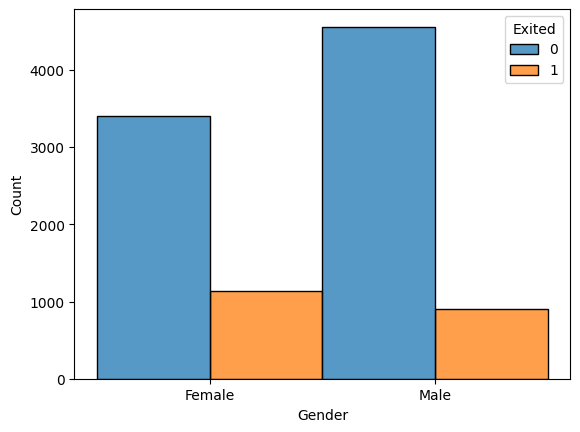

In [63]:
sns.histplot(x = "Gender", hue = data["Exited"], data = data[["Gender", "Geography"]], stat = "count", multiple = "dodge")

In [ ]:
for i, j in enumerate(data[["Geography", "Gender", "Age", "HasCrCard", "IsActiveMember"]]):
    plt.figure()
    sns.histplot(data = data, x = j, hue = data["Exited"], stat = "count", multiple = "dodge")

In [64]:
# for i, j in enumerate(data[["Geography", "Gender", "Age", "HasCrCard", "IsActiveMember"]]):
#     plt.figure(figsize = (8,4))
    
#     sns.histplot(data = data, x = j, hue = data["Exited"], shrink = 0.8, multiple = "dodge")

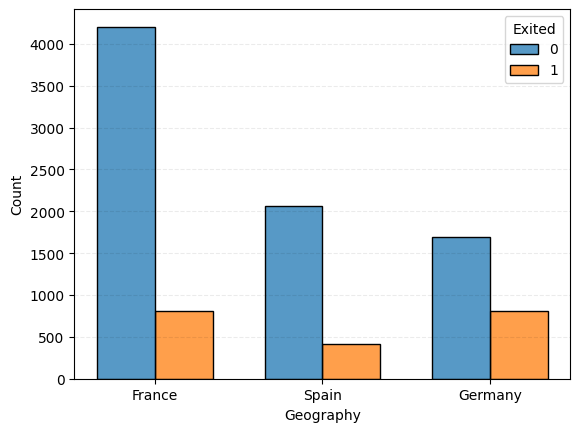

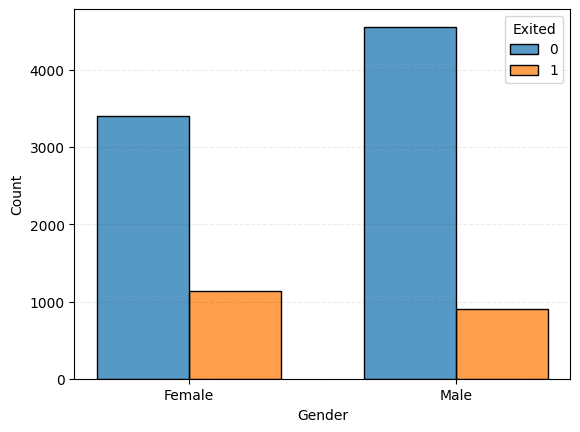

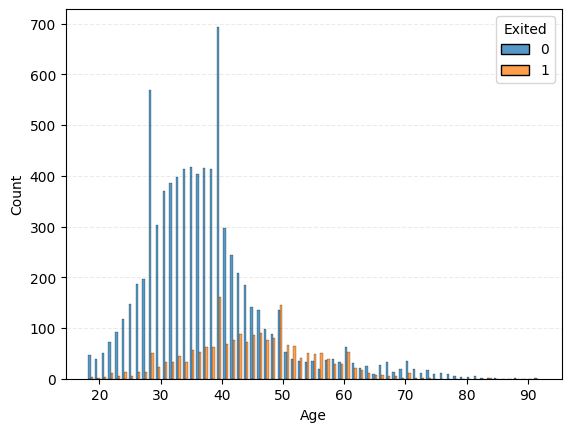

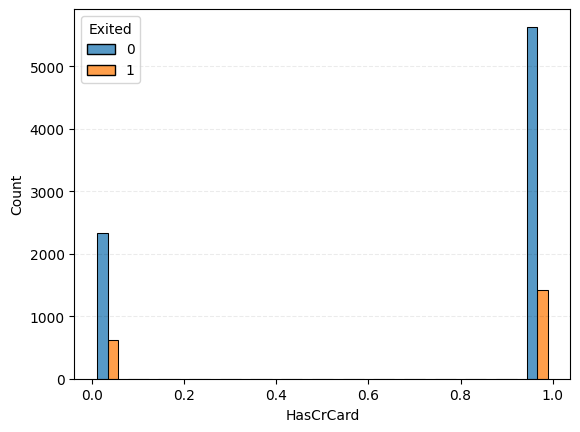

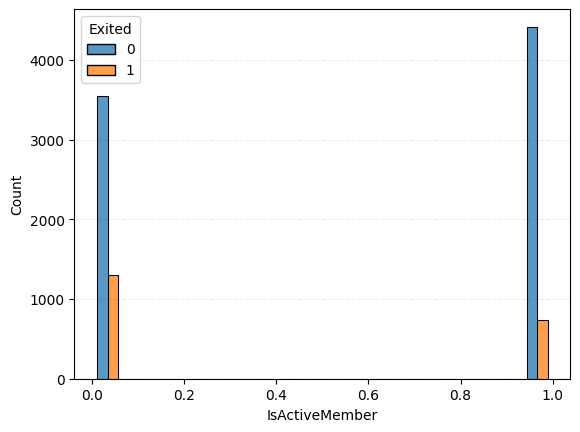

In [65]:
for i, j in enumerate(data[["Geography", "Gender", "Age", "HasCrCard", "IsActiveMember"]]):
    plt.figure()
    sns.histplot(data = data, x = j, shrink = 0.69, hue = data["Exited"], multiple = "dodge")
    plt.grid(color = "Black", alpha = 0.08, axis = "y", linestyle = "--")

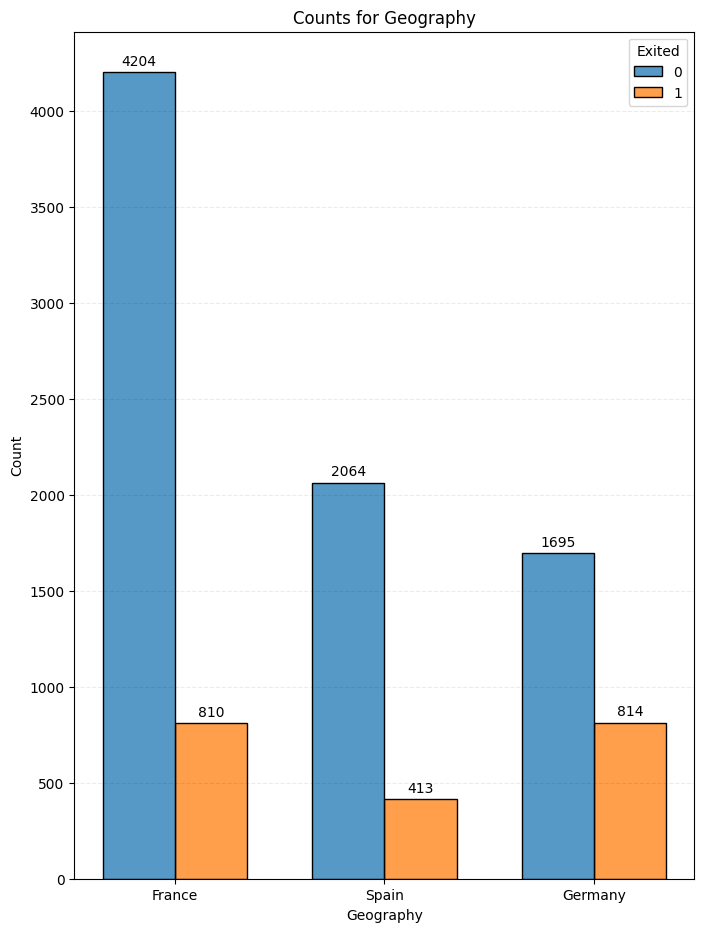

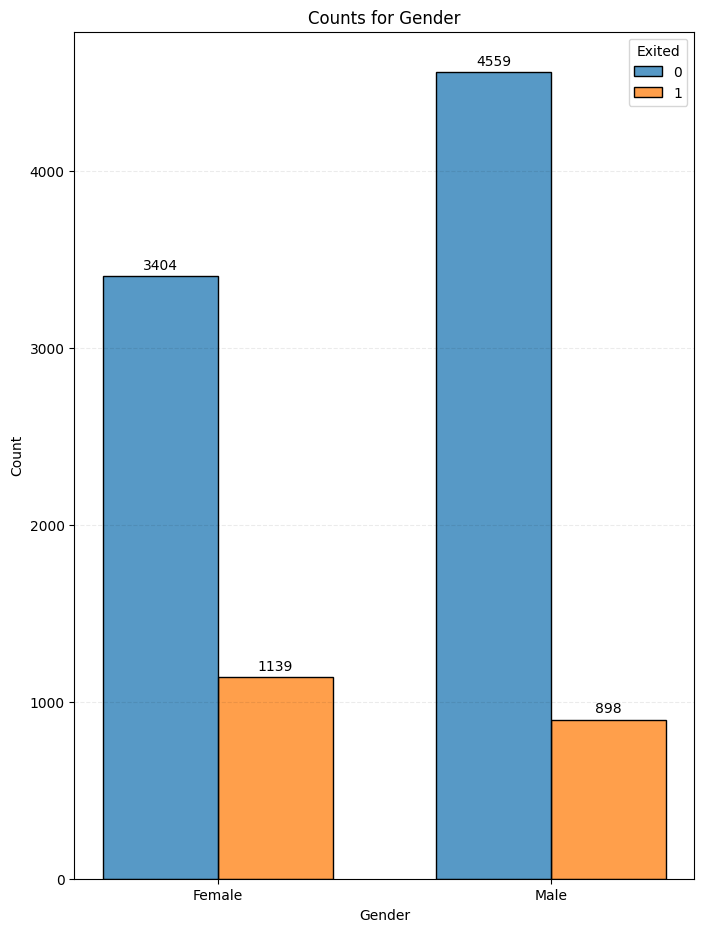

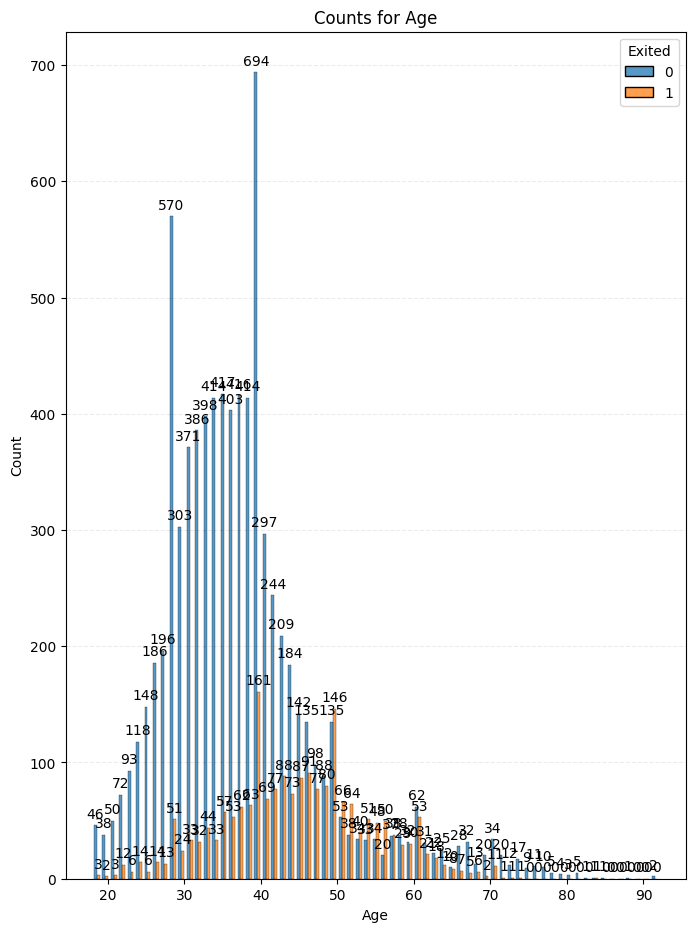

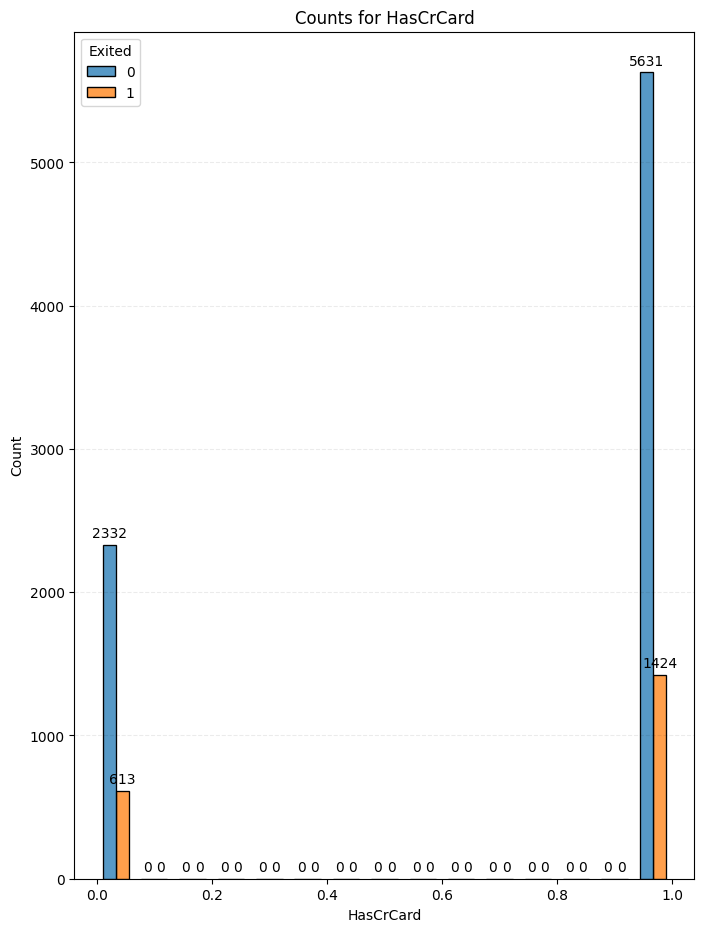

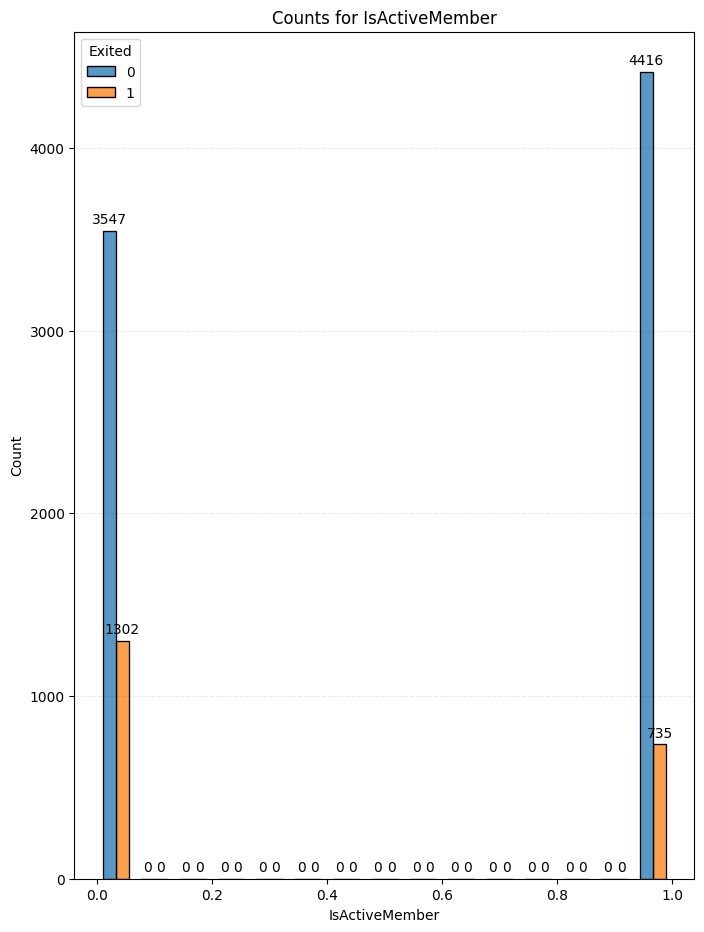

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

cols = ["Geography", "Gender", "Age", "HasCrCard", "IsActiveMember"]

for i, j in enumerate(data[cols]):
    plt.figure(figsize=(8, 11))
    
    # Your original plotting code
    ax = sns.histplot(data=data, x=j, shrink=0.69, hue="Exited", multiple="dodge")
    
    # 1. ADD THIS: Loop through bars and add text labels on top
    for container in ax.containers:
        ax.bar_label(container, padding=3)

    # 2. Add the grid as you requested
    plt.grid(color="Black", alpha=0.08, axis="y", linestyle="--")
    
    plt.title(f"Counts for {j}")
    # plt.savefig(f"{j}_analysis.png", dpi = 350, bbox_inches="tight")
    plt.show()

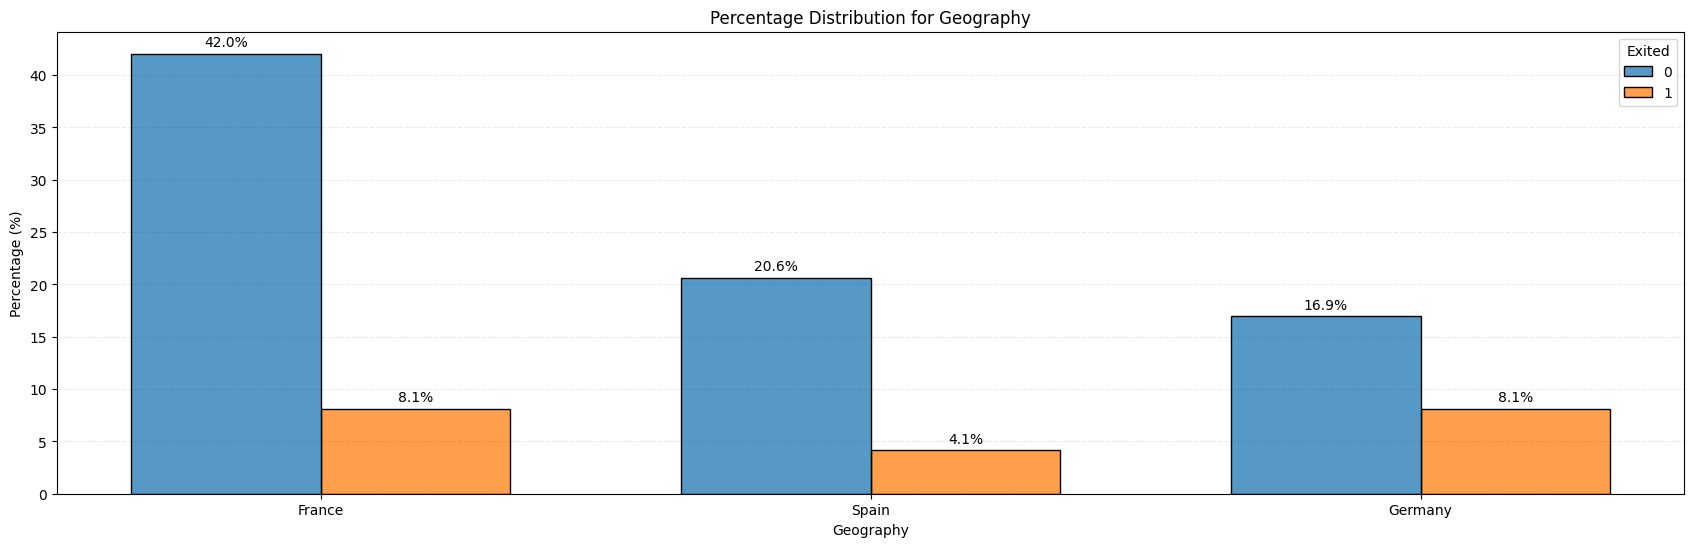

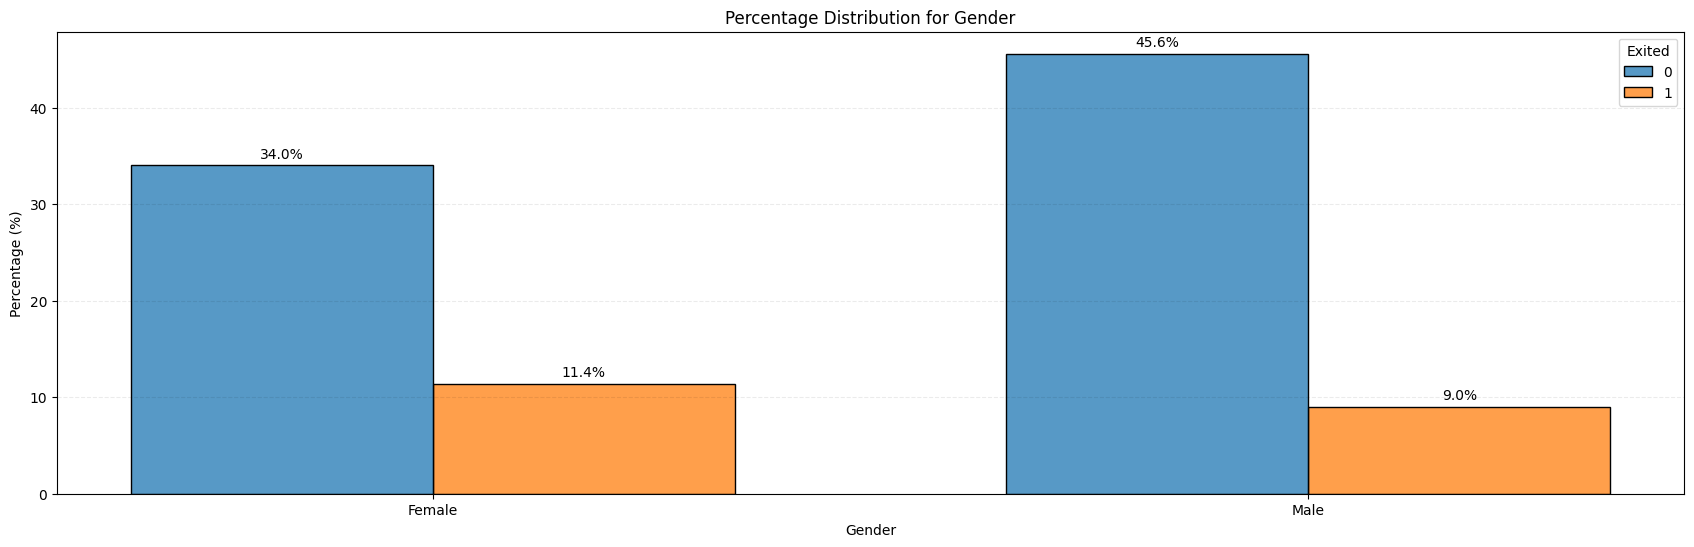

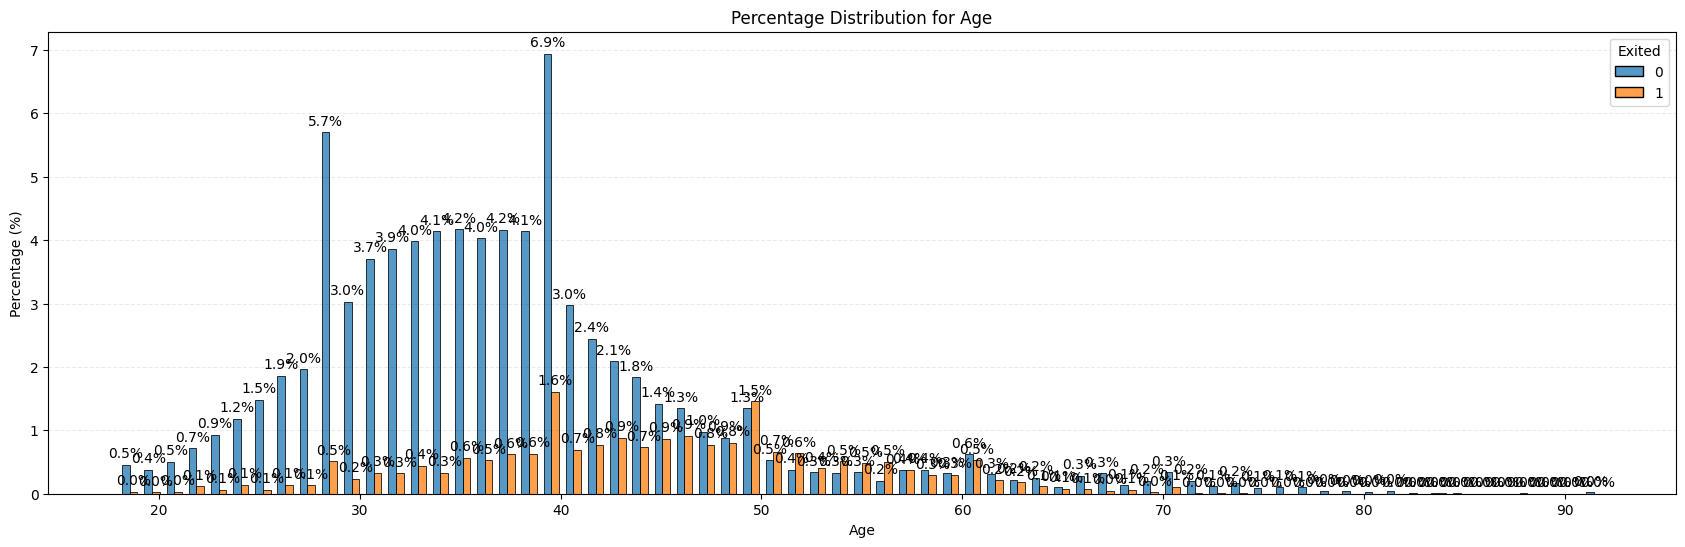

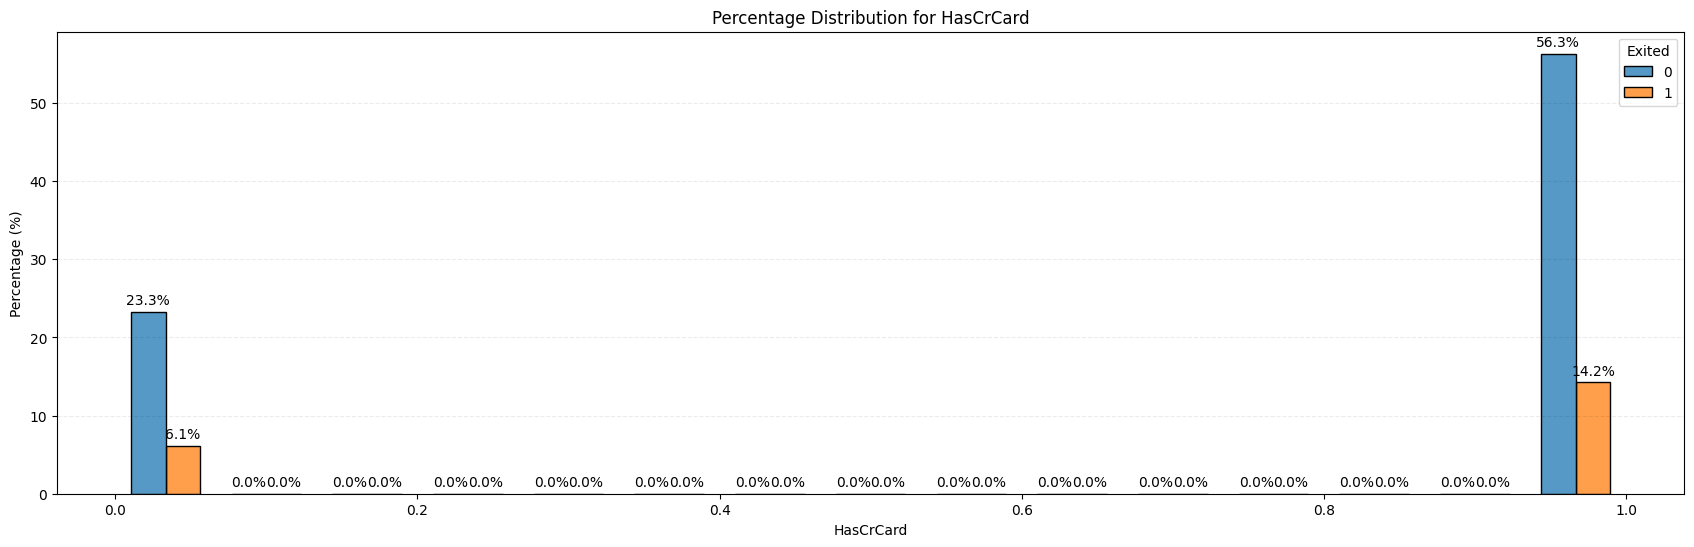

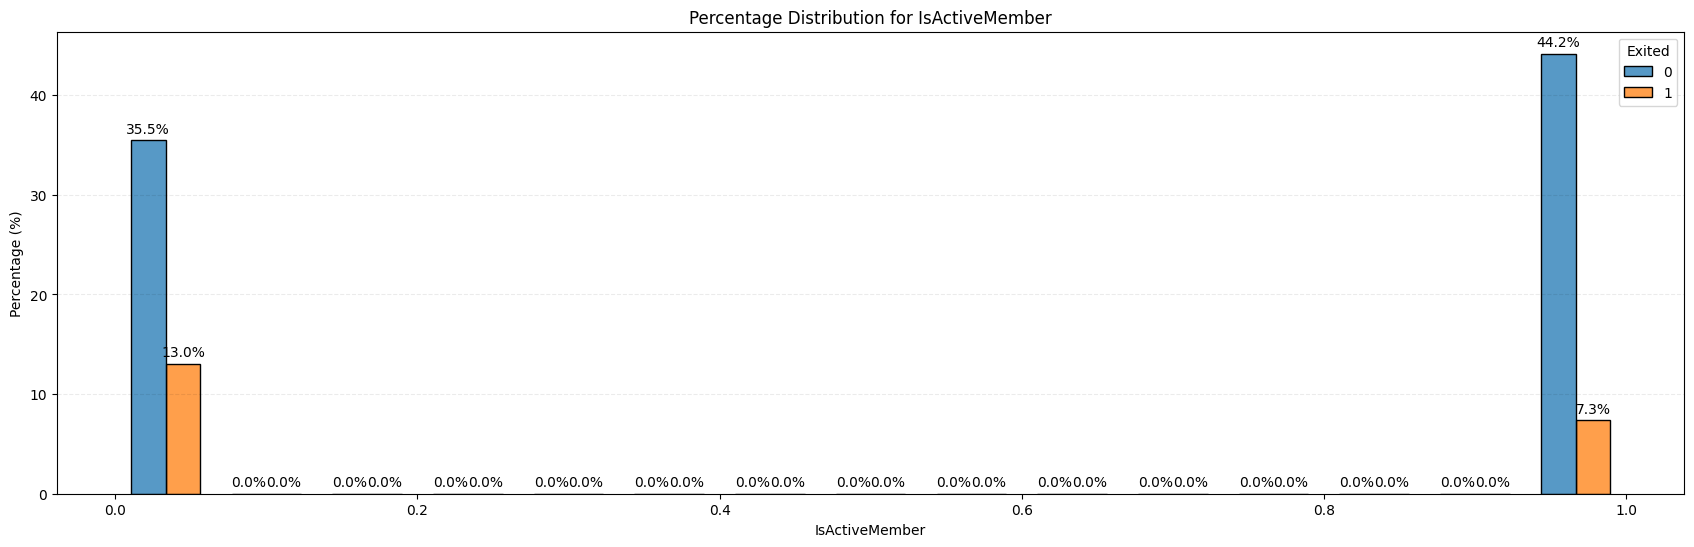

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns

cols = ["Geography", "Gender", "Age", "HasCrCard", "IsActiveMember"]

for i, j in enumerate(data[cols]):
    # Adjusted figsize to be more readable (13x21 is very tall/thin)
    plt.figure(figsize=(21, 6))
    
    # 1. Added stat="percent" to calculate percentages
    # 2. Added common_norm=False so percentages are calculated within each group (Exited vs stayed)
    ax = sns.histplot(data=data, x=j, shrink=0.69, hue="Exited", 
                      multiple="dodge", stat="percent", common_norm=True)
    
    # Loop through bars and add labels
    for container in ax.containers:
        # 3. Added fmt='%.1f%%' to show the percentage symbol on top
        ax.bar_label(container, fmt='%.1f%%', padding=3)

    plt.grid(color="Black", alpha=0.08, axis="y", linestyle="--")
    plt.title(f"Percentage Distribution for {j}")
    plt.ylabel("Percentage (%)") # Updated label
    plt.show()